# Modeling and evaluation

With the EDA done, we know roughly what to expect: setosa should be easy for any model, and most of the classification error will likely fall on the versicolor/virginica boundary. This notebook checks that expectation by comparing several classifiers and inspecting where they actually make mistakes.

In this notebook we will:

* Load the processed feature matrix and 2D projections produced by the previous notebook.
* Compare five classifiers using cross-validated accuracy and macro F1.
* Look at confusion matrices to see which species get confused with which.
* Visualize each model's decision boundary on the 2D PCA projection.
* Inspect feature importances from the tree-based models.
* Save the best model's out-of-fold predictions.

## Imports

First, we import the libraries used throughout this notebook, along with a fixed random seed so cross-validation splits and any stochastic models are reproducible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Load data

We load both the scaled feature matrix used for modeling and the unscaled dataset with the 2D projections, which we use later only for visualization.

In [2]:
features = pd.read_parquet("../data/processed/features.parquet")
data = pd.read_parquet("../data/processed/data.parquet")

X = features.drop(columns=["species"])
y = features["species"]

X.shape, y.value_counts()

((150, 8),
 species
 Iris-setosa        50
 Iris-versicolor    50
 Iris-virginica     50
 Name: count, dtype: int64)

## Model comparison via cross-validation

With only 150 rows split across three classes, a single train/test split would give a noisy, seed-dependent estimate of performance: a model could look better or worse than it really is purely because of which 20-30 rows happened to land in the test set. Stratified 5-fold cross-validation avoids this by evaluating every model on five different held-out folds, each preserving the class balance, and averaging the result, so the reported score reflects the whole dataset rather than one lucky or unlucky split.

We compare five classifiers spanning different modeling approaches: a linear model (Logistic Regression), a distance-based model (KNN), a single tree (Decision Tree), an ensemble of trees (Random Forest), and a margin-based model with a non-linear kernel (SVM with an RBF kernel). This is a small, mostly-separable dataset, so there is no expectation that the more complex models will win; the goal is to check whether that expectation holds.

In [3]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [4]:
results = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=["accuracy", "f1_macro"])
    results.append({
        "model": name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
    })

results_df = pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)
results_df

,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
0,KNN,0.966667,0.042164,0.966617,0.042243
1,SVM (RBF),0.966667,0.042164,0.966617,0.042243
2,Decision Tree,0.966667,0.042164,0.966482,0.042350
3,Logistic Regression,0.960000,0.048990,0.959900,0.049113
4,Random Forest,0.953333,0.033993,0.953115,0.034139


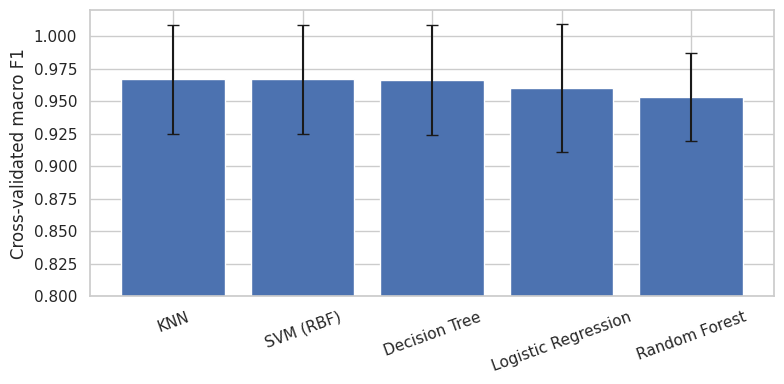

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    results_df["model"],
    results_df["f1_macro_mean"],
    yerr=results_df["f1_macro_std"],
    capsize=4,
)
ax.set_ylabel("Cross-validated macro F1")
ax.set_ylim(0.8, 1.02)
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()

Cross-validated macro F1 ranks the five models within a narrow band: KNN and SVM (RBF) tie for the best score (0.967), the Decision Tree is close behind (0.966), Logistic Regression trails slightly (0.960), and Random Forest scores lowest of the five (0.953). The gap between best and worst is under 1.5 percentage points, consistent with the EDA: most of the signal is easy to find (setosa is trivial, and the petal measurements separate most of the rest), so even a single decision tree captures nearly all of it. The differences that remain come down to how each model handles the versicolor/virginica boundary, which the confusion matrices below make explicit.

## Confusion matrices

Cross-validated scores summarize each model with one number, but say nothing about which species get confused with which. Confusion matrices make this explicit. Since a single train/test split would only show errors from one fold, we use out-of-fold predictions from the same cross-validation splits used above: each row's prediction comes from a fold where that row was held out, so the whole dataset is covered without ever evaluating a model on data it was trained on.

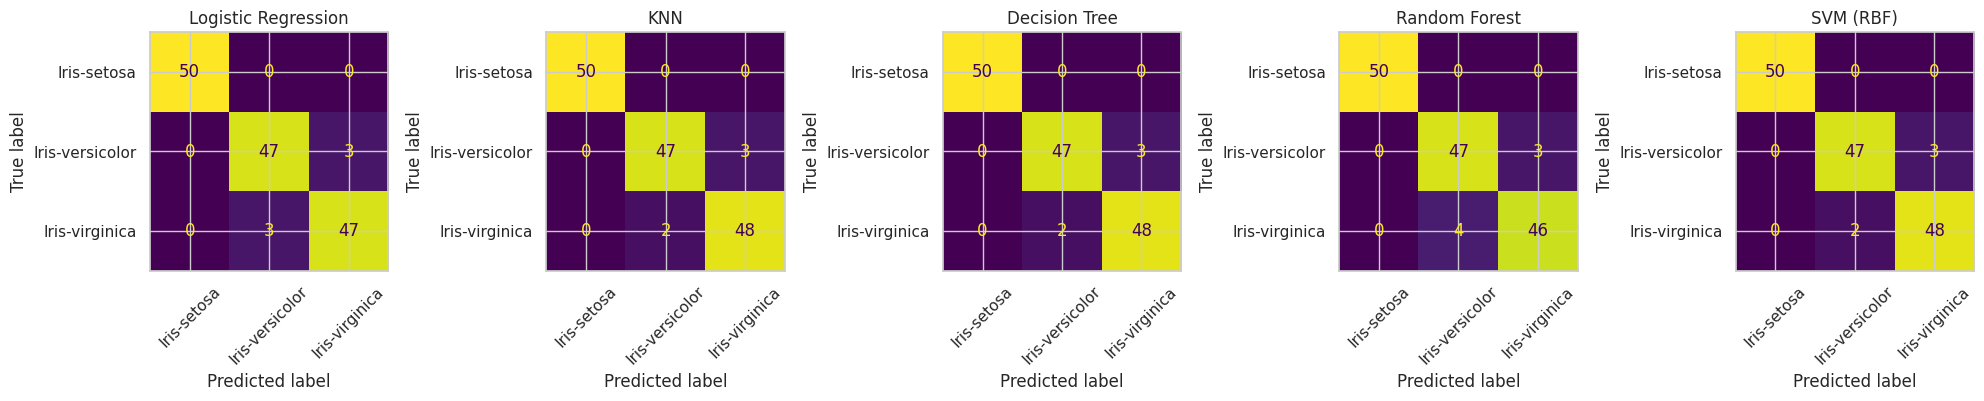

In [6]:
labels = sorted(y.unique())
fig, axes = plt.subplots(1, len(models), figsize=(4 * len(models), 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = cross_val_predict(model, X, y, cv=cv)
    cm = confusion_matrix(y, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(name)
fig.tight_layout()

Every model classifies all 50 setosa flowers correctly, confirming the EDA's expectation that setosa is essentially solved. Every misclassification, across all five models, falls on the versicolor/virginica boundary: 3 versicolor flowers are predicted as virginica in every single model, while the number of virginica flowers predicted as versicolor varies from 2 (KNN, Decision Tree, SVM) to 3 (Logistic Regression) to 4 (Random Forest). This directly explains the F1 ranking above: Random Forest's extra error is exactly why it scores lowest, and the three tied-for-best models make the fewest total errors (5 each, versus 6 for Logistic Regression and 7 for Random Forest).

## Decision boundaries on the 2D projection

The confusion matrices show which species get confused, but not why, in terms of the shape each model learns. To see that, we refit each model on the two PCA components computed in the previous notebook (not the eight-feature matrix used for cross-validation above) purely so its decision regions can be drawn on a 2D plane. These boundaries are for intuition only: a model's real decision surface lives in eight dimensions, and its 2D counterpart here is a simplification which may look more, or less, confident than the actual model.

In [7]:
def plot_decision_boundary(ax, model, X2, y2, title):
    """Fit `model` on a 2D projection and draw its decision regions.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to draw the decision regions and points on.
    model : estimator
        A scikit-learn classifier implementing `fit` and `predict`.
    X2 : ndarray of shape (n_samples, 2)
        Two-dimensional feature matrix used only for this visualization.
    y2 : pandas.Series
        Class labels aligned with `X2`.
    title : str
        Title used for the subplot.
    """
    x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
    y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    model.fit(X2, y2)
    codes = y2.astype("category")
    preds = model.predict(np.c_[xx.ravel(), yy.ravel()])
    preds = pd.Series(preds, dtype=codes.dtype).cat.codes.values.reshape(xx.shape)

    ax.contourf(xx, yy, preds, alpha=0.3, cmap="Set2")
    ax.scatter(X2[:, 0], X2[:, 1], c=codes.cat.codes, cmap="Set2", edgecolor="k", s=20)
    ax.set_title(title)

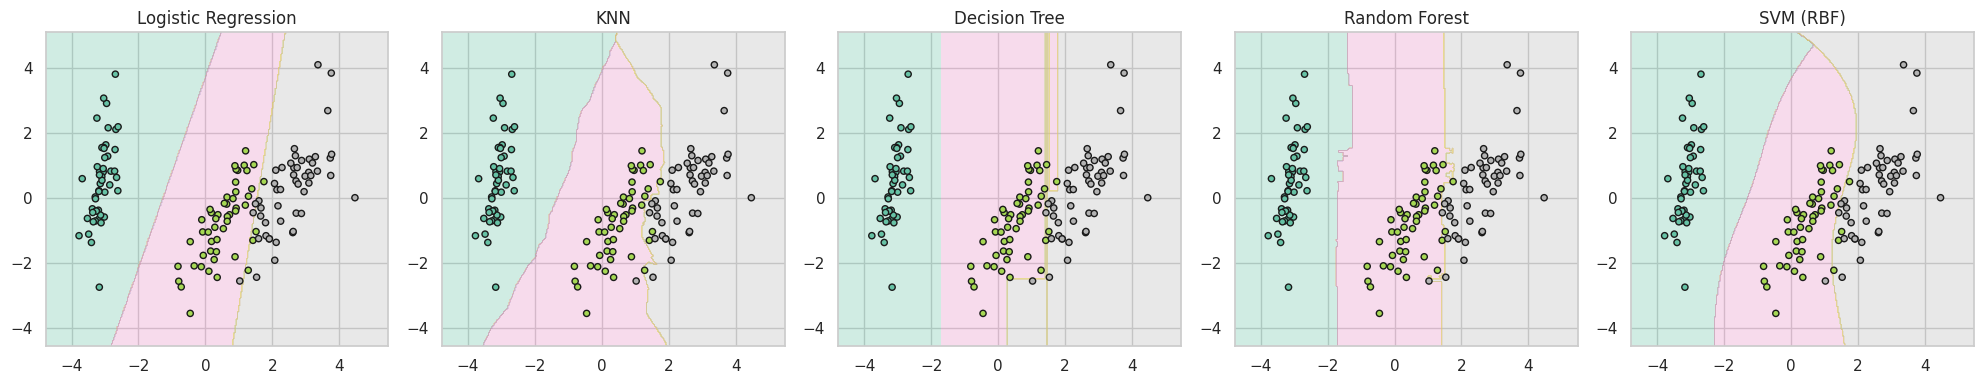

In [8]:
X2 = data[["pca_1", "pca_2"]].values
y2 = data["species"]

fig, axes = plt.subplots(1, len(models), figsize=(4 * len(models), 4))
for ax, (name, model) in zip(axes, models.items()):
    plot_decision_boundary(ax, model, X2, y2, name)
fig.tight_layout()

The plots make the earlier numbers visible as shapes. Logistic Regression draws a single straight boundary between versicolor and virginica, since it is a linear model, while SVM with an RBF kernel can flex that boundary into a smooth curve. The Decision Tree's boundary is visibly rectangular, a signature of splitting on one feature (or projected axis) at a time, while Random Forest's boundary is smoother, an average over many such trees, though not necessarily more accurate here, as the cross-validated scores above showed. KNN's boundary is the most irregular of the five, hugging individual training points closely, which matches how the algorithm works: it has no explicit decision function, only a local vote among nearby points.

## Feature importance

Only the tree-based models (Decision Tree and Random Forest) expose a `feature_importances_` attribute directly, so we look at those two, fit on the full eight-feature matrix (not just the 2D projection used for the plots above) to see which features they actually rely on.

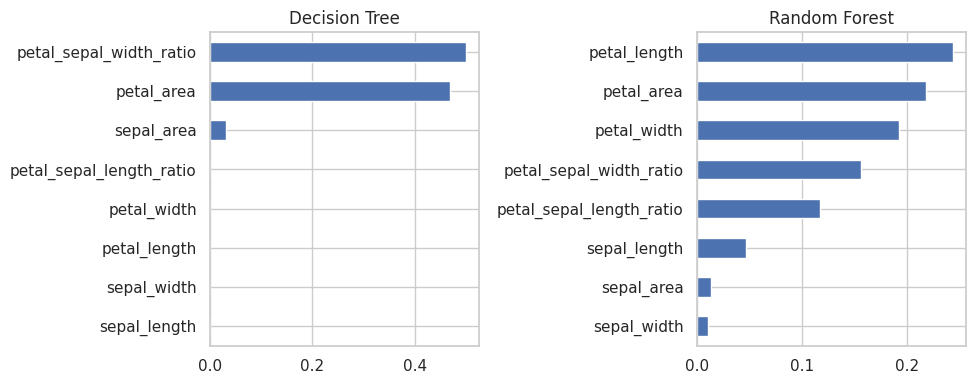

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ["Decision Tree", "Random Forest"]):
    model = models[name]
    model.fit(X, y)
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    importances.plot.barh(ax=ax)
    ax.set_title(name)
fig.tight_layout()

Both models lean almost entirely on petal-related features, raw or engineered, and give the sepal measurements very little weight, consistent with every plot in the previous notebook. The Decision Tree is extreme about this: a single split on `petal_sepal_width_ratio` followed by one on `petal_area` accounts for essentially all of its importance, with zero weight on any raw measurement. Random Forest tells a similar story but spreads the credit more evenly, across `petal_length`, `petal_area`, `petal_width`, and both ratio features, since it averages over many trees rather than committing to whichever feature gives the single best first split.

## Save predictions

As a final step we save the out-of-fold predictions from the best model by cross-validated macro F1, the same predictions used in the confusion matrices above, so they are available for external inspection without re-running the notebook.

In [10]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

predictions = data[["species"]].copy()
predictions["predicted_species"] = cross_val_predict(best_model, X, y, cv=cv)
predictions.to_csv("../data/processed/predictions.csv", index=False)

print("Best model:", best_model_name)
predictions.head()

Best model: KNN


,species,predicted_species
0,Iris-setosa,Iris-setosa
1,Iris-setosa,Iris-setosa
2,Iris-setosa,Iris-setosa
3,Iris-setosa,Iris-setosa
4,Iris-setosa,Iris-setosa


## Closing remarks

Every model here reaches a cross-validated macro F1 above 0.95, and every error, across all five models, falls on the versicolor/virginica boundary identified in the EDA notebook; setosa is classified perfectly in every fold, for every model. KNN and SVM (RBF) tie for the best score (0.967), with the Decision Tree close behind (0.966); KNN is used below for the saved predictions since it appears first among the tied models. For a dataset this small and this clean, the choice of model matters far less than recognizing where the genuine ambiguity in the data lies: versicolor and virginica overlap enough, in petal measurements especially, that no amount of feature engineering or model complexity fully resolves it, and any of the top three models here would be a reasonable choice in practice.